# 00 Pipeline setup and manifest

Run this first. It defines one clean output root and writes a manifest so every later notebook reads the same dataset folder, road shapefile, and GraphML path.

The goal is to prevent a stale route file, stale graph cache, or old GraphML from being mixed into a new run.


In [1]:
from pathlib import Path
import json
import hashlib
import os
import pandas as pd

# =========================================================
# Project paths
# =========================================================
PROJECT_ROOT = Path.cwd()
PIPELINE_ROOT = PROJECT_ROOT / "outputs_pipeline_aligned"
PIPELINE_ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = PROJECT_ROOT / "dataset"
BAODING_DIR = PROJECT_ROOT / "baoding"

GRAPH_DIR = PIPELINE_ROOT / "00_graph"
RAW_SEGMENT_DIR = PIPELINE_ROOT / "01_raw_segments"
VARIABLE_ROOT = PIPELINE_ROOT / "02_variables"
DIAGNOSTIC_MAP_ROOT = PIPELINE_ROOT / "03_diagnostics_maps"
MODEL_ROOT = PIPELINE_ROOT / "04_models"

for p in [GRAPH_DIR, RAW_SEGMENT_DIR, VARIABLE_ROOT, DIAGNOSTIC_MAP_ROOT, MODEL_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

GRAPH_FILE = GRAPH_DIR / "baoding_aligned.graphml"
MANIFEST_PATH = PIPELINE_ROOT / "pipeline_manifest.json"

# =========================================================
# Required raw files
# =========================================================
REQUIRED_DATA_FILES = {
    "all_waybill_info": DATA_DIR / "all_waybill_info.csv",
    "courier_wave_info": DATA_DIR / "courier_wave_info.csv",
    "dispatch_rider": DATA_DIR / "dispatch_rider.csv",
    "dispatch_waybill": DATA_DIR / "dispatch_waybill.csv",
}

missing = [str(p) for p in REQUIRED_DATA_FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required dataset files: %s" % missing)

# Road shapefile. The first candidate matches the current project convention.
road_candidates = [
    BAODING_DIR / "保定数据" / "Road.shp",
    BAODING_DIR / "Road.shp",
]
road_candidates.extend(sorted(BAODING_DIR.rglob("Road.shp")) if BAODING_DIR.exists() else [])

ROAD_SHP = None
for p in road_candidates:
    if p.exists():
        ROAD_SHP = p
        break
if ROAD_SHP is None:
    raise FileNotFoundError("Cannot find Road.shp under baoding folder.")

# Optional POI inputs, used by the variable notebook when present.
poi_candidates = [
    BAODING_DIR / "保定数据" / "POI_保定.shp",
    BAODING_DIR / "POI_保定.shp",
]
rest_candidates = [
    BAODING_DIR / "保定数据" / "大众点评餐馆_保定.shp",
    BAODING_DIR / "大众点评餐馆_保定.shp",
]

POI_INPUT = next((p for p in poi_candidates if p.exists()), None)
REST_INPUT = next((p for p in rest_candidates if p.exists()), None)

# =========================================================
# Fingerprints
# =========================================================
def file_fingerprint(path):
    path = Path(path)
    if not path.exists():
        return None
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(1024 * 1024)
            if not b:
                break
            h.update(b)
    return {
        "path": str(path),
        "size_bytes": int(path.stat().st_size),
        "mtime": float(path.stat().st_mtime),
        "md5": h.hexdigest(),
    }

manifest = {
    "project_root": str(PROJECT_ROOT),
    "pipeline_root": str(PIPELINE_ROOT),
    "data_dir": str(DATA_DIR),
    "baoding_dir": str(BAODING_DIR),
    "road_shp": str(ROAD_SHP),
    "graph_file": str(GRAPH_FILE),
    "raw_segment_dir": str(RAW_SEGMENT_DIR),
    "variable_root": str(VARIABLE_ROOT),
    "diagnostic_map_root": str(DIAGNOSTIC_MAP_ROOT),
    "model_root": str(MODEL_ROOT),
    "poi_input": str(POI_INPUT) if POI_INPUT is not None else None,
    "restaurant_input": str(REST_INPUT) if REST_INPUT is not None else None,
    "raw_file_fingerprints": {k: file_fingerprint(v) for k, v in REQUIRED_DATA_FILES.items()},
    "road_shp_fingerprint": file_fingerprint(ROAD_SHP),
}

MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
print("Manifest written:", MANIFEST_PATH)
print(json.dumps(manifest, indent=2, ensure_ascii=False))


Manifest written: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\pipeline_manifest.json
{
  "project_root": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan",
  "pipeline_root": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\outputs_pipeline_aligned",
  "data_dir": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\dataset",
  "baoding_dir": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\baoding",
  "road_shp": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\baoding\\保定数据\\Road.shp",
  "graph_file": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\outputs_pipeline_aligned\\00_graph\\baoding_aligned.graphml",
  "raw_segment_dir": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\outputs_pipeline_aligned\\01_raw_segments",
  "variable_root": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\outputs_pipeline_aligned\\02_variables",
  "diagnostic_map_root": "c:\\Users\\Kwk10\\Desktop\\2026 Spring\\Meituan\\outputs_pipeline_aligned\\03_diagnostics_maps",
  "mode

In [2]:
# Quick input table size check
for name, path in REQUIRED_DATA_FILES.items():
    df_head = pd.read_csv(path, nrows=5)
    print(name, "columns=", list(df_head.columns)[:10], "...")
print("Road shapefile:", ROAD_SHP)
print("Optional POI:", POI_INPUT)
print("Optional restaurant POI:", REST_INPUT)


all_waybill_info columns= ['Unnamed: 0', 'dt', 'order_id', 'waybill_id', 'courier_id', 'da_id', 'is_courier_grabbed', 'is_weekend', 'estimate_arrived_time', 'is_prebook'] ...
courier_wave_info columns= ['dt', 'courier_id', 'wave_id', 'wave_start_time', 'wave_end_time', 'order_ids'] ...
dispatch_rider columns= ['Unnamed: 0', 'dt', 'rider_lat', 'rider_lng', 'dispatch_time', 'courier_waybills', 'courier_id'] ...
dispatch_waybill columns= ['Unnamed: 0', 'dt', 'dispatch_time', 'order_id'] ...
Road shapefile: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\baoding\保定数据\Road.shp
Optional POI: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\baoding\保定数据\POI_保定.shp
Optional restaurant POI: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\baoding\保定数据\大众点评餐馆_保定.shp


Loading raw order data: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\dataset\all_waybill_info.csv
Timestamp column used: platform_order_time
Rows in raw waybill table: 654,343
Unique orders after dedup by order_id: 568,546, removed duplicate waybill rows: 85,797

Order activity summary
Observed local date range: 2022-10-11 to 2022-10-24
Observed dates: 13
Total counted orders: 568,546
Peak observed date: 2022-10-23, 77,668 orders
Peak hour of day: 11:00, 94,869 orders in total
Peak date-hour: 2022-10-22 11:00, 12,168 orders

Top 10 active hours by total order count:


,hour,order_count,avg_orders_per_observed_day
0,11,94869,7297.615385
1,18,65520,5040.000000
2,12,57744,4441.846154
3,17,52621,4047.769231
4,19,45474,3498.000000
5,10,37510,2885.384615
6,20,29702,2284.769231
7,13,29119,2239.923077
8,16,24761,1904.692308
9,14,21090,1622.307692



Saved figure: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_order_activity_week_day.png
Saved daily CSV: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_order_activity_daily_counts.csv
Saved hourly CSV: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_order_activity_hourly_counts.csv
Saved day-of-week-hour CSV: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_order_activity_dayofweek_hour_counts.csv


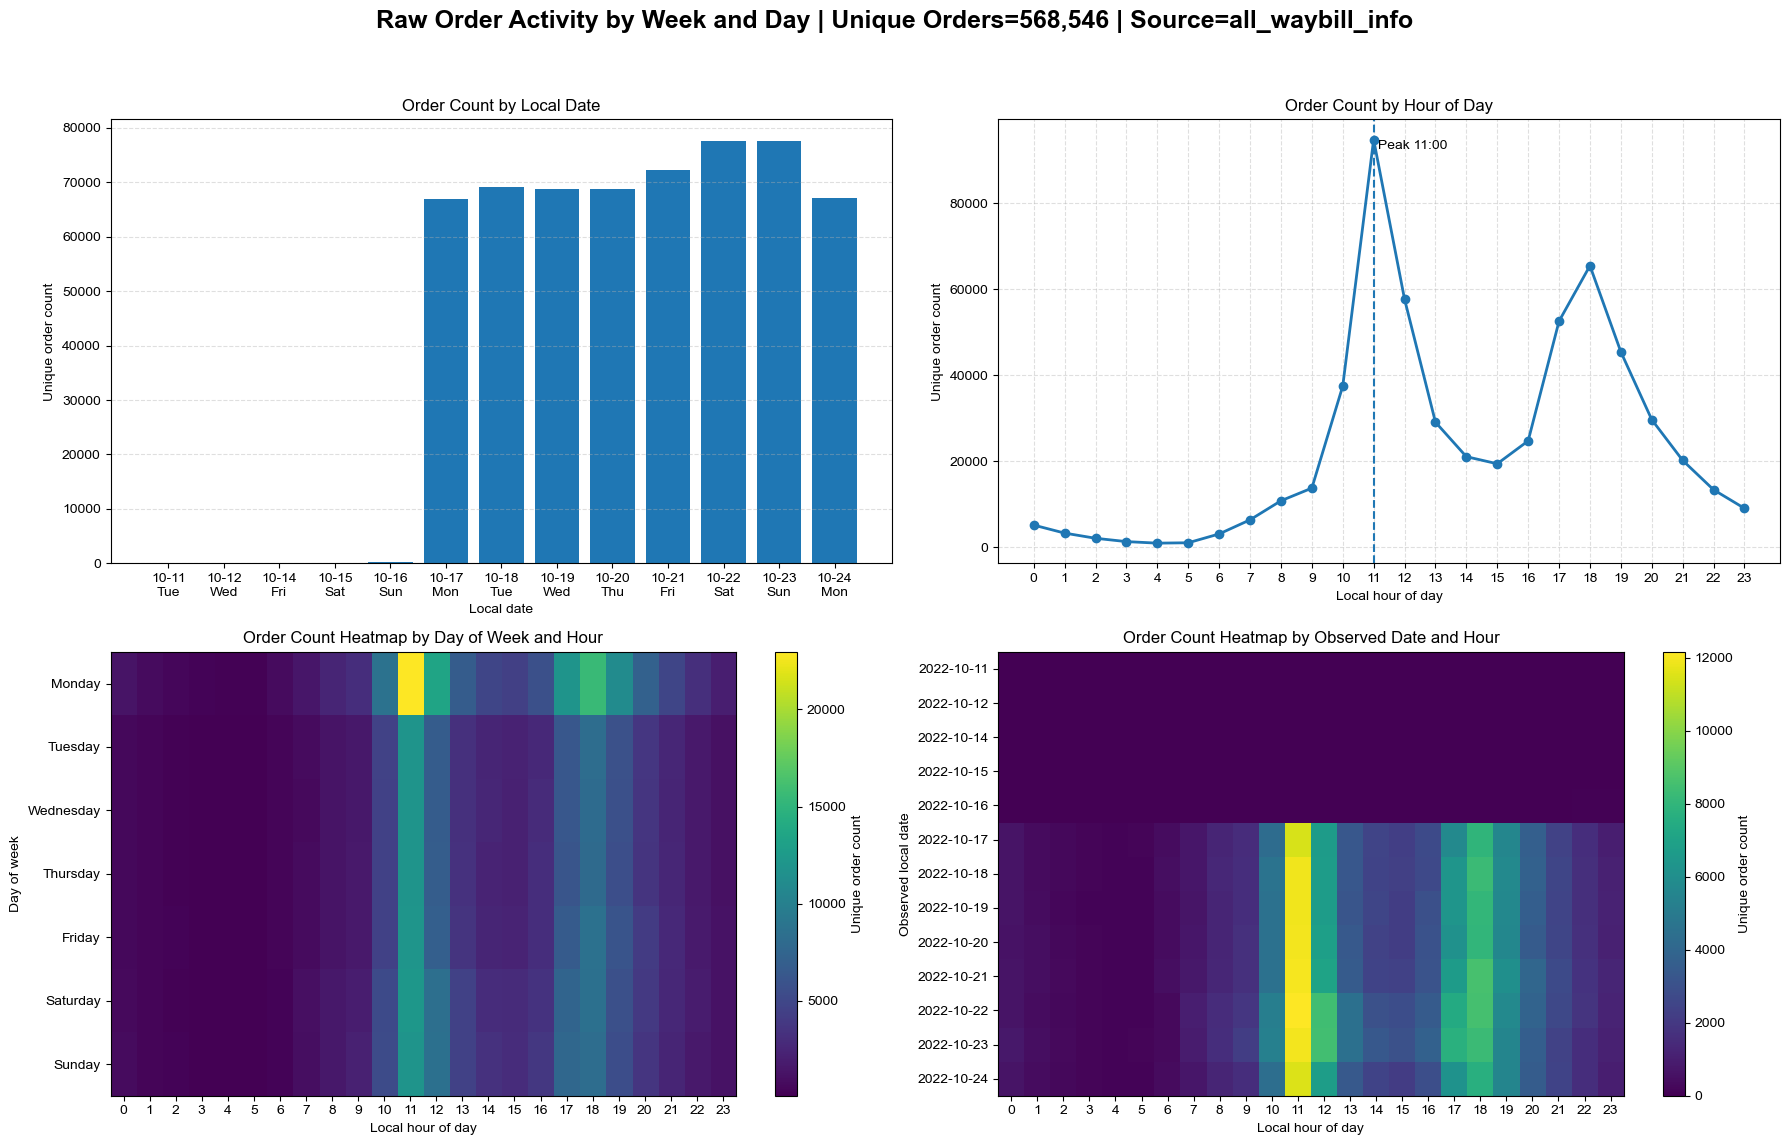

In [3]:
# =========================================================
# 00.X Raw order activity figure
#      Weekly and daily active periods based on order count
#      Count unique orders from all_waybill_info, not trip segments
#      Python 3.8 compatible
# =========================================================

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

RUN_RAW_ORDER_ACTIVITY_FIGURE = True

# Preferred timestamp for order demand.
# platform_order_time is the order creation time in the raw waybill table.
ORDER_ACTIVITY_TIME_COL = "platform_order_time"
ORDER_ACTIVITY_FALLBACK_TIME_COLS = [
    "platform_order_time",
    "order_push_time",
    "dispatch_time",
]

# Count unique order_id so rejected or re-dispatched waybills do not inflate demand.
ORDER_ACTIVITY_ID_COL = "order_id"
DEDUP_ORDER_ACTIVITY_BY_ORDER_ID = True

# Convert Unix time to local operational time.
# The raw timestamps are Unix seconds. Use +8 for China local time.
ORDER_ACTIVITY_TZ_SHIFT_HOURS = 8

# Optional date filter in local time.
# Use None to keep the whole raw data period.
ORDER_ACTIVITY_START_DATE = None  # example: "2022-10-17"
ORDER_ACTIVITY_END_DATE = None    # example: "2022-10-23"

# Output folder.
try:
    ORDER_ACTIVITY_OUTPUT_DIR = PIPELINE_ROOT / "00_manifest_diagnostics"
except NameError:
    ORDER_ACTIVITY_OUTPUT_DIR = Path("./outputs_pipeline_aligned/00_manifest_diagnostics")

ORDER_ACTIVITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FIG_ORDER_ACTIVITY = ORDER_ACTIVITY_OUTPUT_DIR / "raw_order_activity_week_day.png"
OUTPUT_CSV_ORDER_ACTIVITY_HOURLY = ORDER_ACTIVITY_OUTPUT_DIR / "raw_order_activity_hourly_counts.csv"
OUTPUT_CSV_ORDER_ACTIVITY_DAILY = ORDER_ACTIVITY_OUTPUT_DIR / "raw_order_activity_daily_counts.csv"
OUTPUT_CSV_ORDER_ACTIVITY_DOW_HOUR = ORDER_ACTIVITY_OUTPUT_DIR / "raw_order_activity_dayofweek_hour_counts.csv"

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------

def _get_raw_waybill_path():
    if "REQUIRED_DATA_FILES" in globals() and "all_waybill_info" in REQUIRED_DATA_FILES:
        return Path(REQUIRED_DATA_FILES["all_waybill_info"])
    return Path("./dataset/all_waybill_info.csv")


def _choose_time_col(df):
    if ORDER_ACTIVITY_TIME_COL in df.columns:
        return ORDER_ACTIVITY_TIME_COL
    for c in ORDER_ACTIVITY_FALLBACK_TIME_COLS:
        if c in df.columns:
            return c
    raise ValueError(
        "Cannot find a usable order timestamp column. Tried: %s"
        % ORDER_ACTIVITY_FALLBACK_TIME_COLS
    )


def _fmt_int(x):
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

# ---------------------------------------------------------
# Main
# ---------------------------------------------------------

if RUN_RAW_ORDER_ACTIVITY_FIGURE:
    raw_waybill_path = _get_raw_waybill_path()
    if not raw_waybill_path.exists():
        raise FileNotFoundError("Cannot find all_waybill_info raw file: %s" % raw_waybill_path)

    print("Loading raw order data:", raw_waybill_path)

    # Read the full raw waybill table because we need order_id and timestamp only.
    # Reading selected columns is safer across memory limits.
    header_cols = pd.read_csv(raw_waybill_path, nrows=0).columns.tolist()
    candidate_cols = list(dict.fromkeys(
        [ORDER_ACTIVITY_ID_COL, "waybill_id", "dt"] + ORDER_ACTIVITY_FALLBACK_TIME_COLS
    ))
    usecols = [c for c in candidate_cols if c in header_cols]

    orders_raw = pd.read_csv(raw_waybill_path, usecols=usecols)
    time_col = _choose_time_col(orders_raw)

    print("Timestamp column used:", time_col)
    print("Rows in raw waybill table:", _fmt_int(len(orders_raw)))

    orders_raw[time_col] = pd.to_numeric(orders_raw[time_col], errors="coerce")
    orders_raw = orders_raw[orders_raw[time_col].notna() & (orders_raw[time_col] > 0)].copy()

    if DEDUP_ORDER_ACTIVITY_BY_ORDER_ID and ORDER_ACTIVITY_ID_COL in orders_raw.columns:
        before = len(orders_raw)
        orders_raw = orders_raw.sort_values(time_col).drop_duplicates(
            subset=[ORDER_ACTIVITY_ID_COL],
            keep="first",
        )
        after = len(orders_raw)
        print(
            "Unique orders after dedup by %s: %s, removed duplicate waybill rows: %s"
            % (ORDER_ACTIVITY_ID_COL, _fmt_int(after), _fmt_int(before - after))
        )
    else:
        print("Counting rows because order_id is unavailable or dedup is disabled.")

    orders_raw["order_time_utc"] = pd.to_datetime(
        orders_raw[time_col],
        unit="s",
        utc=True,
        errors="coerce",
    )
    orders_raw["order_time_local"] = orders_raw["order_time_utc"] + pd.Timedelta(
        hours=ORDER_ACTIVITY_TZ_SHIFT_HOURS
    )

    orders_raw = orders_raw[orders_raw["order_time_local"].notna()].copy()

    if ORDER_ACTIVITY_START_DATE is not None:
        start_ts = pd.Timestamp(ORDER_ACTIVITY_START_DATE)
        orders_raw = orders_raw[orders_raw["order_time_local"].dt.tz_localize(None) >= start_ts].copy()

    if ORDER_ACTIVITY_END_DATE is not None:
        end_ts = pd.Timestamp(ORDER_ACTIVITY_END_DATE) + pd.Timedelta(days=1)
        orders_raw = orders_raw[orders_raw["order_time_local"].dt.tz_localize(None) < end_ts].copy()

    if len(orders_raw) == 0:
        raise ValueError("No order rows remain after time cleaning and date filters.")

    orders_raw["local_date"] = orders_raw["order_time_local"].dt.date
    orders_raw["hour"] = orders_raw["order_time_local"].dt.hour.astype(int)
    orders_raw["weekday"] = orders_raw["order_time_local"].dt.weekday.astype(int)
    orders_raw["weekday_name"] = orders_raw["order_time_local"].dt.day_name()
    orders_raw["date_hour"] = orders_raw["order_time_local"].dt.floor("H")

    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    daily_counts = (
        orders_raw.groupby("local_date")
        .size()
        .rename("order_count")
        .reset_index()
    )
    daily_counts["local_date"] = pd.to_datetime(daily_counts["local_date"])
    daily_counts["weekday_name"] = daily_counts["local_date"].dt.day_name()
    daily_counts = daily_counts.sort_values("local_date")

    hourly_counts = (
        orders_raw.groupby("hour")
        .size()
        .rename("order_count")
        .reindex(range(24), fill_value=0)
        .reset_index()
    )

    date_hour_counts = (
        orders_raw.groupby(["local_date", "hour"])
        .size()
        .rename("order_count")
        .reset_index()
    )
    n_dates = daily_counts["local_date"].dt.date.nunique()
    hourly_counts["avg_orders_per_observed_day"] = hourly_counts["order_count"] / max(n_dates, 1)

    dow_hour_counts = (
        orders_raw.groupby(["weekday", "weekday_name", "hour"])
        .size()
        .rename("order_count")
        .reset_index()
    )

    dow_hour_pivot = (
        dow_hour_counts.pivot_table(
            index="weekday_name",
            columns="hour",
            values="order_count",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(weekday_order)
        .fillna(0)
    )
    dow_hour_pivot = dow_hour_pivot.reindex(columns=list(range(24)), fill_value=0)

    date_hour_pivot = (
        date_hour_counts.pivot_table(
            index="local_date",
            columns="hour",
            values="order_count",
            aggfunc="sum",
            fill_value=0,
        )
        .sort_index()
    )
    date_hour_pivot = date_hour_pivot.reindex(columns=list(range(24)), fill_value=0)

    # Save tables for inspection.
    tmp_daily = OUTPUT_CSV_ORDER_ACTIVITY_DAILY.with_suffix(OUTPUT_CSV_ORDER_ACTIVITY_DAILY.suffix + ".tmp")
    daily_counts.to_csv(tmp_daily, index=False)
    os.replace(str(tmp_daily), str(OUTPUT_CSV_ORDER_ACTIVITY_DAILY))

    tmp_hourly = OUTPUT_CSV_ORDER_ACTIVITY_HOURLY.with_suffix(OUTPUT_CSV_ORDER_ACTIVITY_HOURLY.suffix + ".tmp")
    hourly_counts.to_csv(tmp_hourly, index=False)
    os.replace(str(tmp_hourly), str(OUTPUT_CSV_ORDER_ACTIVITY_HOURLY))

    dow_hour_out = dow_hour_pivot.reset_index()
    tmp_dow = OUTPUT_CSV_ORDER_ACTIVITY_DOW_HOUR.with_suffix(OUTPUT_CSV_ORDER_ACTIVITY_DOW_HOUR.suffix + ".tmp")
    dow_hour_out.to_csv(tmp_dow, index=False)
    os.replace(str(tmp_dow), str(OUTPUT_CSV_ORDER_ACTIVITY_DOW_HOUR))

    # Console diagnosis.
    print("\nOrder activity summary")
    print("Observed local date range: %s to %s" % (daily_counts["local_date"].min().date(), daily_counts["local_date"].max().date()))
    print("Observed dates:", n_dates)
    print("Total counted orders:", _fmt_int(len(orders_raw)))

    peak_day = daily_counts.loc[daily_counts["order_count"].idxmax()]
    peak_hour = hourly_counts.loc[hourly_counts["order_count"].idxmax()]
    peak_date_hour = date_hour_counts.loc[date_hour_counts["order_count"].idxmax()]

    print("Peak observed date: %s, %s orders" % (peak_day["local_date"].date(), _fmt_int(peak_day["order_count"])))
    print("Peak hour of day: %02d:00, %s orders in total" % (int(peak_hour["hour"]), _fmt_int(peak_hour["order_count"])))
    print(
        "Peak date-hour: %s %02d:00, %s orders"
        % (peak_date_hour["local_date"], int(peak_date_hour["hour"]), _fmt_int(peak_date_hour["order_count"]))
    )

    print("\nTop 10 active hours by total order count:")
    display(
        hourly_counts.sort_values("order_count", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    # -----------------------------------------------------
    # Figure
    # -----------------------------------------------------

    plt.rcParams["font.sans-serif"] = ["Arial"]
    plt.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(
        "Raw Order Activity by Week and Day | Unique Orders=%s | Source=all_waybill_info"
        % _fmt_int(len(orders_raw)),
        fontsize=18,
        fontweight="bold",
    )

    # Panel 1. Daily order count in observed period.
    ax = axes[0, 0]
    x = np.arange(len(daily_counts))
    ax.bar(x, daily_counts["order_count"].values)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [d.strftime("%m-%d\n%a") for d in daily_counts["local_date"]],
        rotation=0,
    )
    ax.set_title("Order Count by Local Date")
    ax.set_xlabel("Local date")
    ax.set_ylabel("Unique order count")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Panel 2. Hour-of-day order count.
    ax = axes[0, 1]
    ax.plot(hourly_counts["hour"], hourly_counts["order_count"], marker="o", linewidth=2)
    ax.set_xticks(range(0, 24, 1))
    ax.set_title("Order Count by Hour of Day")
    ax.set_xlabel("Local hour of day")
    ax.set_ylabel("Unique order count")
    ax.grid(True, linestyle="--", alpha=0.4)

    peak_hour_int = int(peak_hour["hour"])
    ax.axvline(peak_hour_int, linestyle="--", linewidth=1.5)
    ax.text(
        peak_hour_int,
        float(hourly_counts["order_count"].max()),
        " Peak %02d:00" % peak_hour_int,
        va="top",
        ha="left",
    )

    # Panel 3. Day-of-week by hour heatmap.
    ax = axes[1, 0]
    im = ax.imshow(dow_hour_pivot.values, aspect="auto")
    ax.set_title("Order Count Heatmap by Day of Week and Hour")
    ax.set_xlabel("Local hour of day")
    ax.set_ylabel("Day of week")
    ax.set_xticks(range(24))
    ax.set_yticks(range(len(dow_hour_pivot.index)))
    ax.set_yticklabels(dow_hour_pivot.index)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Unique order count")

    # Panel 4. Observed date by hour heatmap.
    ax = axes[1, 1]
    im2 = ax.imshow(date_hour_pivot.values, aspect="auto")
    ax.set_title("Order Count Heatmap by Observed Date and Hour")
    ax.set_xlabel("Local hour of day")
    ax.set_ylabel("Observed local date")
    ax.set_xticks(range(24))
    ax.set_yticks(range(len(date_hour_pivot.index)))
    ax.set_yticklabels([str(x) for x in date_hour_pivot.index])
    cbar2 = plt.colorbar(im2, ax=ax)
    cbar2.set_label("Unique order count")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    tmp_fig = OUTPUT_FIG_ORDER_ACTIVITY.with_suffix(OUTPUT_FIG_ORDER_ACTIVITY.suffix + ".tmp.png")
    plt.savefig(tmp_fig, dpi=180, bbox_inches="tight")
    os.replace(str(tmp_fig), str(OUTPUT_FIG_ORDER_ACTIVITY))

    print("\nSaved figure:", OUTPUT_FIG_ORDER_ACTIVITY)
    print("Saved daily CSV:", OUTPUT_CSV_ORDER_ACTIVITY_DAILY)
    print("Saved hourly CSV:", OUTPUT_CSV_ORDER_ACTIVITY_HOURLY)
    print("Saved day-of-week-hour CSV:", OUTPUT_CSV_ORDER_ACTIVITY_DOW_HOUR)

    plt.show()




DA ID distribution from raw all_waybill_info
Input: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\dataset\all_waybill_info.csv
Location columns: sender_lat sender_lng
Dedup by order_id: True
Raw rows: 654,343
Rows after order_id dedup: 568,546, removed: 85,797
Rows after coordinate cleaning: 566,939

DA ID count summary:
Number of DA IDs: 23
Top DA order share: 97.94%

Top 30 DA IDs:


,da_id,order_count,share_pct,rank
0,0,115229,20.324762,1
22,9,64446,11.367361,2
18,5,62090,10.951796,3
20,7,41262,7.278032,4
19,6,40286,7.105879,5
12,2,28473,5.022233,6
1,1,24196,4.267831,7
16,3,23163,4.085625,8
10,18,20726,3.655772,9
5,13,18925,3.338102,10


Saved DA counts: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_da_id_counts.csv
Saved DA centroids: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_da_id_centroids.csv


C:\Users\Kwk10\AppData\Local\Temp\ipykernel_12172\4065460667.py:292: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(top_da_ids), 1))



Saved DA distribution figure: c:\Users\Kwk10\Desktop\2026 Spring\Meituan\outputs_pipeline_aligned\00_manifest_diagnostics\raw_da_id_distribution_map.png


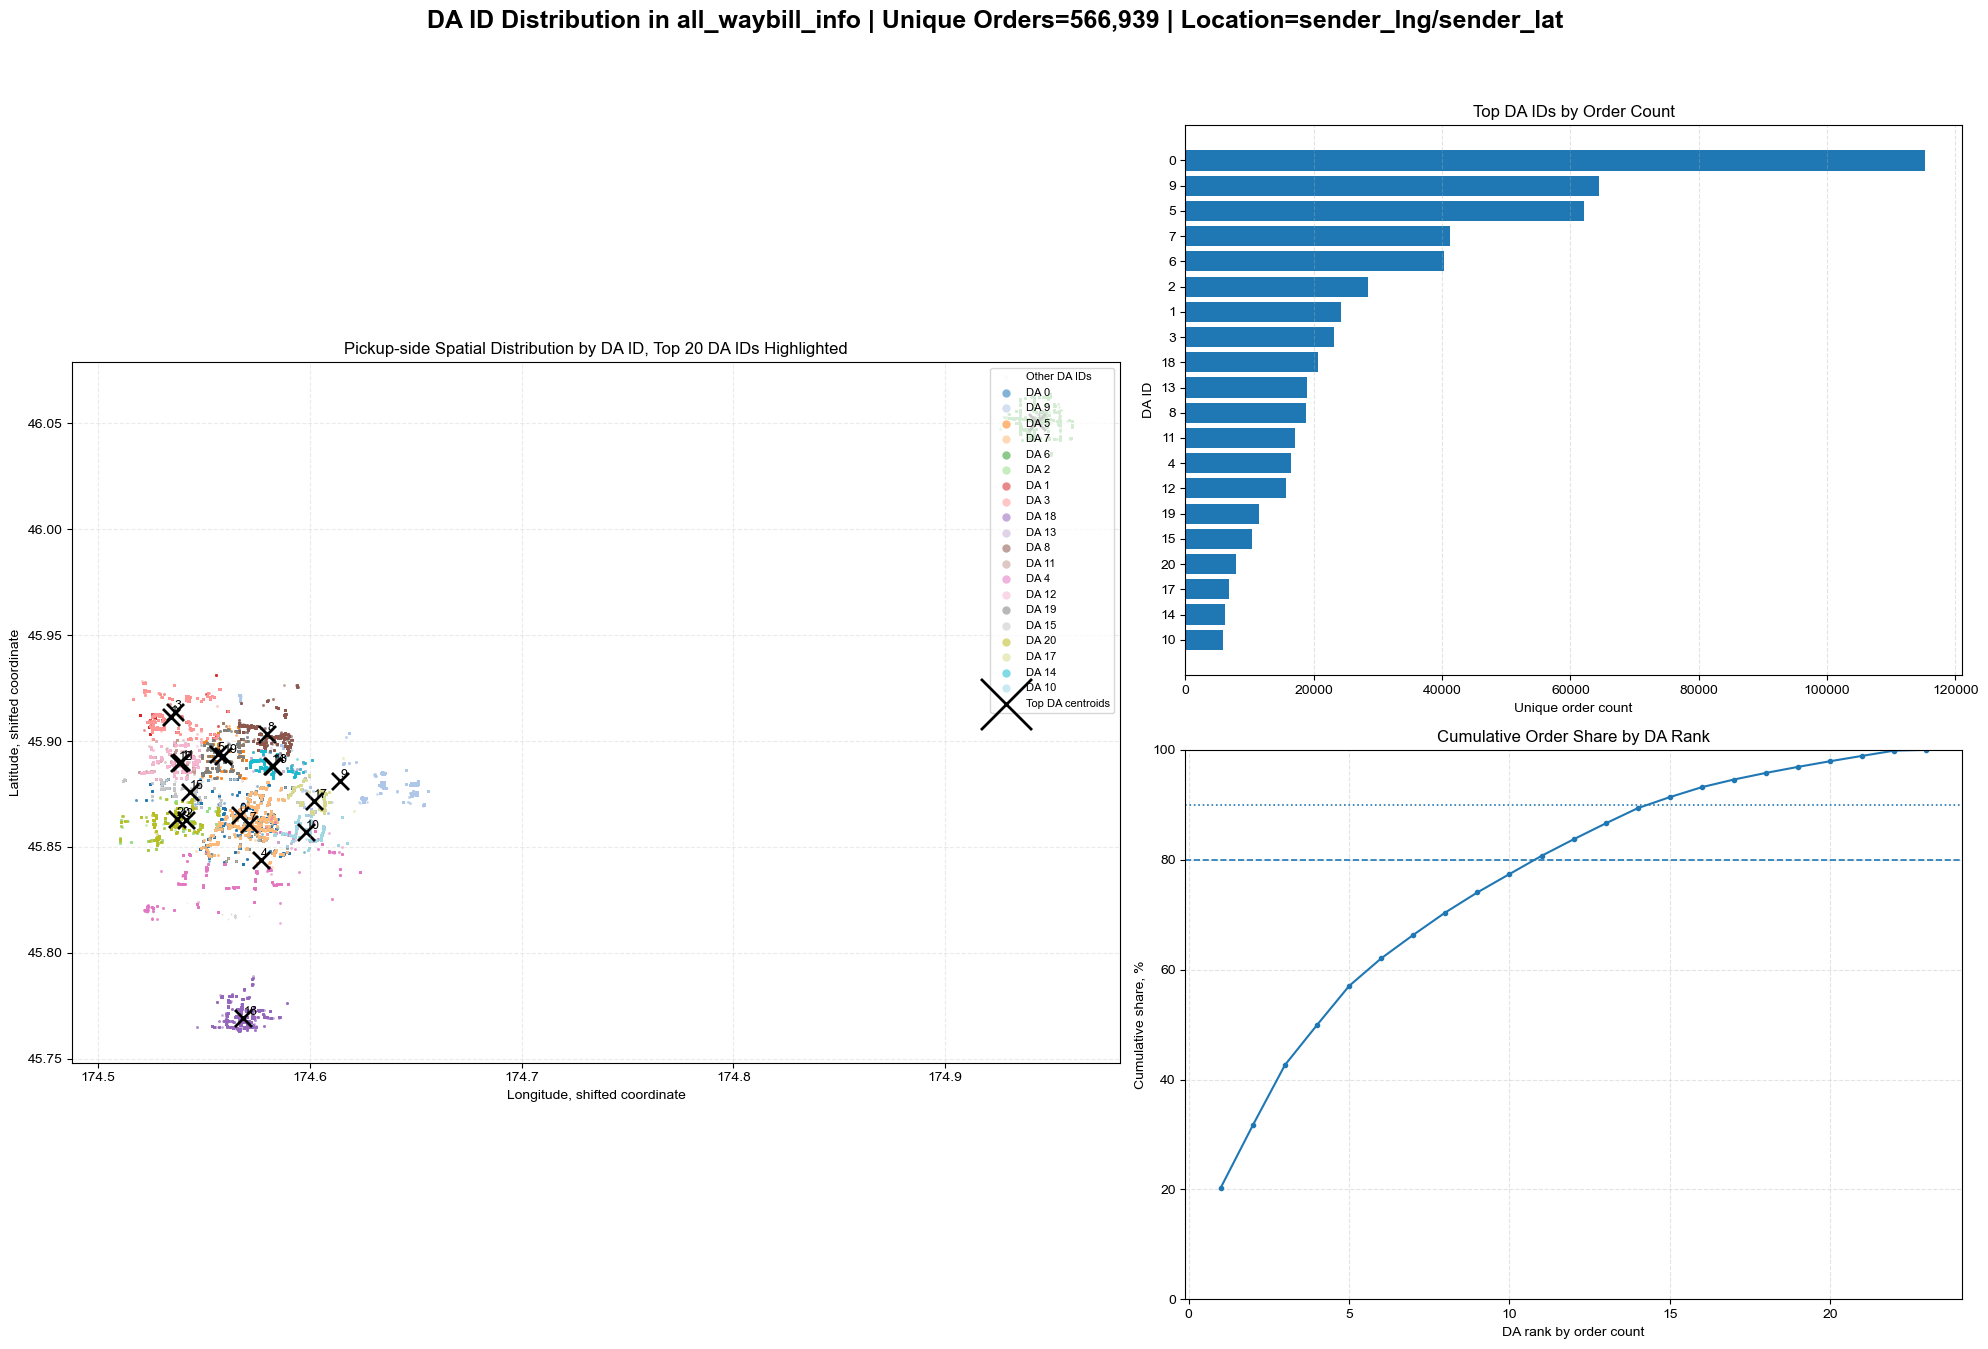

In [4]:
# =========================================================
# 00.X DA ID distribution map from all_waybill_info
#      Distribution of da_id based on raw orders, not trip segments
#      Python 3.8 compatible
# =========================================================

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

RUN_DA_ID_DISTRIBUTION_MAP = True

# Raw order file.
try:
    DA_RAW_WAYBILL_PATH = Path(REQUIRED_DATA_FILES["all_waybill_info"])
except Exception:
    DA_RAW_WAYBILL_PATH = Path("./dataset/all_waybill_info.csv")

# Output folder.
try:
    DA_OUTPUT_DIR = PIPELINE_ROOT / "00_manifest_diagnostics"
except NameError:
    DA_OUTPUT_DIR = Path("./outputs_pipeline_aligned/00_manifest_diagnostics")

DA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FIG_DA_DISTRIBUTION = DA_OUTPUT_DIR / "raw_da_id_distribution_map.png"
OUTPUT_CSV_DA_COUNTS = DA_OUTPUT_DIR / "raw_da_id_counts.csv"
OUTPUT_CSV_DA_CENTROIDS = DA_OUTPUT_DIR / "raw_da_id_centroids.csv"

# Counting logic.
# True: one order_id counted once.
# False: each waybill row counted once.
DEDUP_DA_BY_ORDER_ID = True
ORDER_ID_COL_FOR_DA = "order_id"

# Location logic.
# sender_* is usually better for DA demand geography because it is merchant / pickup side.
DA_LAT_COL = "sender_lat"
DA_LNG_COL = "sender_lng"

# Optional alternative:
# DA_LAT_COL = "recipient_lat"
# DA_LNG_COL = "recipient_lng"

DA_ID_COL = "da_id"

# Plot controls.
TOP_K_DA_TO_COLOR = 20
SCATTER_SAMPLE_N = 120000
RANDOM_SEED = 42

POINT_SIZE_TOP_DA = 4
POINT_SIZE_OTHER_DA = 1
POINT_ALPHA_TOP_DA = 0.55
POINT_ALPHA_OTHER_DA = 0.08

CENTROID_SIZE = 150
CENTROID_LABEL_TOP_K = 20

FIGSIZE = (20, 14)
DPI = 180


# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------

def _safe_write_csv(df_out, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df_out.to_csv(tmp, index=index)
    os.replace(str(tmp), str(path))


def _fmt_int(x):
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _auto_scale_coord(s):
    x = pd.to_numeric(s, errors="coerce")
    vmax = x.abs().quantile(0.99)

    if pd.isna(vmax):
        return x

    # Common anonymized coordinate storage is integer degrees multiplied by 1e6.
    if vmax > 1000:
        return x / 1e6

    return x


def _clean_da_map_data(df):
    out = df.copy()

    out[DA_ID_COL] = out[DA_ID_COL].astype(str)
    out[DA_LAT_COL] = _auto_scale_coord(out[DA_LAT_COL])
    out[DA_LNG_COL] = _auto_scale_coord(out[DA_LNG_COL])

    out = out[
        out[DA_ID_COL].notna()
        & (out[DA_ID_COL].astype(str).str.lower() != "nan")
        & out[DA_LAT_COL].notna()
        & out[DA_LNG_COL].notna()
        & (out[DA_LAT_COL] != 0)
        & (out[DA_LNG_COL] != 0)
    ].copy()

    # Remove extreme coordinate noise using broad quantile trimming.
    lat_low, lat_high = out[DA_LAT_COL].quantile([0.001, 0.999])
    lng_low, lng_high = out[DA_LNG_COL].quantile([0.001, 0.999])

    out = out[
        out[DA_LAT_COL].between(lat_low, lat_high)
        & out[DA_LNG_COL].between(lng_low, lng_high)
    ].copy()

    return out


# ---------------------------------------------------------
# Main
# ---------------------------------------------------------

if RUN_DA_ID_DISTRIBUTION_MAP:

    if not DA_RAW_WAYBILL_PATH.exists():
        raise FileNotFoundError("Cannot find all_waybill_info file: %s" % DA_RAW_WAYBILL_PATH)

    print("\n" + "=" * 70)
    print("DA ID distribution from raw all_waybill_info")
    print("=" * 70)
    print("Input:", DA_RAW_WAYBILL_PATH)
    print("Location columns:", DA_LAT_COL, DA_LNG_COL)
    print("Dedup by order_id:", DEDUP_DA_BY_ORDER_ID)

    header_cols = pd.read_csv(DA_RAW_WAYBILL_PATH, nrows=0).columns.tolist()

    required = [DA_ID_COL, DA_LAT_COL, DA_LNG_COL]
    for c in required:
        if c not in header_cols:
            raise ValueError("Missing required column in all_waybill_info: %s" % c)

    usecols = required[:]
    if ORDER_ID_COL_FOR_DA in header_cols:
        usecols.append(ORDER_ID_COL_FOR_DA)
    if "waybill_id" in header_cols:
        usecols.append("waybill_id")
    if "dt" in header_cols:
        usecols.append("dt")
    if "platform_order_time" in header_cols:
        usecols.append("platform_order_time")

    usecols = list(dict.fromkeys(usecols))

    da_raw = pd.read_csv(DA_RAW_WAYBILL_PATH, usecols=usecols)
    print("Raw rows:", _fmt_int(len(da_raw)))

    if DEDUP_DA_BY_ORDER_ID and ORDER_ID_COL_FOR_DA in da_raw.columns:
        before = len(da_raw)

        if "platform_order_time" in da_raw.columns:
            da_raw["platform_order_time"] = pd.to_numeric(
                da_raw["platform_order_time"],
                errors="coerce",
            )
            da_raw = da_raw.sort_values("platform_order_time")

        da_raw = da_raw.drop_duplicates(subset=[ORDER_ID_COL_FOR_DA], keep="first").copy()

        print(
            "Rows after order_id dedup: %s, removed: %s"
            % (_fmt_int(len(da_raw)), _fmt_int(before - len(da_raw)))
        )

    da_df = _clean_da_map_data(da_raw)
    print("Rows after coordinate cleaning:", _fmt_int(len(da_df)))

    if len(da_df) == 0:
        raise ValueError("No valid rows after DA and coordinate cleaning.")

    # -----------------------------------------------------
    # DA counts and centroids
    # -----------------------------------------------------

    da_counts = (
        da_df.groupby(DA_ID_COL)
        .size()
        .rename("order_count")
        .reset_index()
        .sort_values("order_count", ascending=False)
    )
    da_counts["share_pct"] = da_counts["order_count"] / da_counts["order_count"].sum() * 100
    da_counts["rank"] = np.arange(1, len(da_counts) + 1)

    top_da_ids = da_counts.head(TOP_K_DA_TO_COLOR)[DA_ID_COL].astype(str).tolist()

    da_df["da_plot_group"] = np.where(
        da_df[DA_ID_COL].astype(str).isin(top_da_ids),
        da_df[DA_ID_COL].astype(str),
        "Other DA IDs",
    )

    da_centroids = (
        da_df.groupby(DA_ID_COL)
        .agg(
            order_count=(DA_ID_COL, "size"),
            lng_mean=(DA_LNG_COL, "mean"),
            lat_mean=(DA_LAT_COL, "mean"),
            lng_median=(DA_LNG_COL, "median"),
            lat_median=(DA_LAT_COL, "median"),
            lng_std=(DA_LNG_COL, "std"),
            lat_std=(DA_LAT_COL, "std"),
        )
        .reset_index()
        .sort_values("order_count", ascending=False)
    )
    da_centroids["share_pct"] = da_centroids["order_count"] / da_centroids["order_count"].sum() * 100
    da_centroids["rank"] = np.arange(1, len(da_centroids) + 1)

    _safe_write_csv(da_counts, OUTPUT_CSV_DA_COUNTS, index=False)
    _safe_write_csv(da_centroids, OUTPUT_CSV_DA_CENTROIDS, index=False)

    print("\nDA ID count summary:")
    print("Number of DA IDs:", _fmt_int(da_counts[DA_ID_COL].nunique()))
    print("Top DA order share: %.2f%%" % da_counts.head(TOP_K_DA_TO_COLOR)["share_pct"].sum())

    print("\nTop 30 DA IDs:")
    display(da_counts.head(30))

    print("Saved DA counts:", OUTPUT_CSV_DA_COUNTS)
    print("Saved DA centroids:", OUTPUT_CSV_DA_CENTROIDS)

    # -----------------------------------------------------
    # Sampling for scatter plotting
    # -----------------------------------------------------

    if len(da_df) > SCATTER_SAMPLE_N:
        da_plot = da_df.sample(SCATTER_SAMPLE_N, random_state=RANDOM_SEED).copy()
    else:
        da_plot = da_df.copy()

    # Plot Other first, then top DA groups on top.
    other_plot = da_plot[da_plot["da_plot_group"] == "Other DA IDs"].copy()
    top_plot = da_plot[da_plot["da_plot_group"] != "Other DA IDs"].copy()

    top_centroids = da_centroids.head(CENTROID_LABEL_TOP_K).copy()

    # -----------------------------------------------------
    # Figure
    # -----------------------------------------------------

    fig = plt.figure(figsize=FIGSIZE)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.35, 1.0], height_ratios=[1.0, 1.0])

    ax_map = fig.add_subplot(gs[:, 0])
    ax_bar = fig.add_subplot(gs[0, 1])
    ax_share = fig.add_subplot(gs[1, 1])

    fig.suptitle(
        "DA ID Distribution in all_waybill_info | Unique Orders=%s | Location=%s/%s"
        % (_fmt_int(len(da_df)), DA_LNG_COL, DA_LAT_COL),
        fontsize=18,
        fontweight="bold",
    )

    # Main map.
    if len(other_plot) > 0:
        ax_map.scatter(
            other_plot[DA_LNG_COL],
            other_plot[DA_LAT_COL],
            s=POINT_SIZE_OTHER_DA,
            alpha=POINT_ALPHA_OTHER_DA,
            c="lightgray",
            linewidths=0,
            label="Other DA IDs",
        )

    cmap = plt.cm.get_cmap("tab20", max(len(top_da_ids), 1))

    for i, da_id in enumerate(top_da_ids):
        sub = top_plot[top_plot[DA_ID_COL].astype(str) == str(da_id)]
        if len(sub) == 0:
            continue

        ax_map.scatter(
            sub[DA_LNG_COL],
            sub[DA_LAT_COL],
            s=POINT_SIZE_TOP_DA,
            alpha=POINT_ALPHA_TOP_DA,
            color=cmap(i % 20),
            linewidths=0,
            label="DA %s" % da_id,
        )

    # Centroids.
    ax_map.scatter(
        top_centroids["lng_mean"],
        top_centroids["lat_mean"],
        s=CENTROID_SIZE,
        c="black",
        marker="x",
        linewidths=2.0,
        label="Top DA centroids",
    )

    for _, r in top_centroids.iterrows():
        ax_map.text(
            r["lng_mean"],
            r["lat_mean"],
            str(r[DA_ID_COL]),
            fontsize=9,
            color="black",
            ha="left",
            va="bottom",
        )

    ax_map.set_title(
        "Pickup-side Spatial Distribution by DA ID, Top %d DA IDs Highlighted"
        % TOP_K_DA_TO_COLOR
    )
    ax_map.set_xlabel("Longitude, shifted coordinate")
    ax_map.set_ylabel("Latitude, shifted coordinate")
    ax_map.set_aspect("equal", adjustable="box")
    ax_map.grid(True, linestyle="--", alpha=0.25)

    # Keep legend compact.
    handles, labels = ax_map.get_legend_handles_labels()
    if len(handles) > 0:
        ax_map.legend(
            handles[:TOP_K_DA_TO_COLOR + 2],
            labels[:TOP_K_DA_TO_COLOR + 2],
            loc="upper right",
            fontsize=8,
            frameon=True,
            markerscale=3,
        )

    # Bar chart for top DA counts.
    top_counts = da_counts.head(TOP_K_DA_TO_COLOR).copy()
    ax_bar.barh(
        top_counts[DA_ID_COL].astype(str)[::-1],
        top_counts["order_count"].values[::-1],
    )
    ax_bar.set_title("Top DA IDs by Order Count")
    ax_bar.set_xlabel("Unique order count")
    ax_bar.set_ylabel("DA ID")
    ax_bar.grid(axis="x", linestyle="--", alpha=0.35)

    # Cumulative share.
    da_counts_sorted = da_counts.sort_values("rank").copy()
    da_counts_sorted["cum_share_pct"] = da_counts_sorted["share_pct"].cumsum()

    ax_share.plot(
        da_counts_sorted["rank"],
        da_counts_sorted["cum_share_pct"],
        marker="o",
        markersize=3,
        linewidth=1.5,
    )
    ax_share.axhline(80, linestyle="--", linewidth=1.2)
    ax_share.axhline(90, linestyle=":", linewidth=1.2)
    ax_share.set_title("Cumulative Order Share by DA Rank")
    ax_share.set_xlabel("DA rank by order count")
    ax_share.set_ylabel("Cumulative share, %")
    ax_share.set_ylim(0, 100)
    ax_share.grid(True, linestyle="--", alpha=0.35)

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])

    tmp_fig = OUTPUT_FIG_DA_DISTRIBUTION.with_suffix(
        OUTPUT_FIG_DA_DISTRIBUTION.suffix + ".tmp.png"
    )
    plt.savefig(tmp_fig, dpi=DPI, bbox_inches="tight")
    os.replace(str(tmp_fig), str(OUTPUT_FIG_DA_DISTRIBUTION))

    print("\nSaved DA distribution figure:", OUTPUT_FIG_DA_DISTRIBUTION)
    plt.show()